In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/Group Project')

['Voyage Analytics_ Integrating MLOps in Travel Productionization of ML Systems.pptx',
 'flights.csv',
 'hotels.csv',
 'users.csv',
 'Copy of Untitled']

In [ ]:
#load Dataset
users = pd.read_csv('/content/drive/MyDrive/Group Project/users.csv')
hotels =pd.read_csv('/content/drive/MyDrive/Group Project/hotels.csv')
flights = pd.read_csv('/content/drive/MyDrive/Group Project/flights.csv')

In [ ]:
users.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


In [ ]:
flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [ ]:
hotels.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In  dataset, the **code** column in **users.csv** corresponds to the **userCode** column in both **flights.csv** and **hotels.csv**.

so
users.code = flights.usercode
users.code = hotels.usercode

also both **flights.csv** and **hotel.csv** contains **travelcode**

we can use as

travelcode =trip id

usercode = user id

In [ ]:
hotels.rename(columns={'name': 'hotel name'}, inplace=True)
hotels.columns

Index(['travelCode', 'userCode', 'hotel name', 'place', 'days', 'price',
       'total', 'date'],
      dtype='object')

In [ ]:
users.rename(columns={'name': 'user name'}, inplace=True)
users.columns

Index(['code', 'company', 'user name', 'gender', 'age'], dtype='object')

merge flights.csv and hotels.csv

In [ ]:
flights_users = flights.merge(users, left_on="userCode", right_on="code",how="left")
hotels_users = hotels.merge(users, left_on="userCode", right_on="code", how="left")

In [ ]:
travel_df = pd.merge(flights,hotels, on=["travelCode", "userCode"],how="inner")
travel_df.head()

,travelCode,userCode,from,to,flightType,price_x,time,distance,agency,date_x,hotel name,place,days,price_y,total,date_y
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
2,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
3,2,0,Salvador (BH),Aracaju (SE),firstClass,1531.92,2.16,830.86,CloudFy,10/12/2019,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
4,7,0,Aracaju (SE),Salvador (BH),economic,964.83,2.16,830.86,CloudFy,11/14/2019,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019


merge users

In [ ]:
df = pd.merge(travel_df, users, left_on='userCode', right_on='code', how='left')
df.head()

,travelCode,userCode,from,to,flightType,price_x,time,distance,agency,date_x,...,place,days,price_y,total,date_y,code,company,user name,gender,age
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019,...,Florianopolis (SC),4,313.02,1252.08,09/26/2019,0,4You,Roy Braun,male,21
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019,...,Florianopolis (SC),4,313.02,1252.08,09/26/2019,0,4You,Roy Braun,male,21
2,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019,...,Salvador (BH),2,263.41,526.82,10/10/2019,0,4You,Roy Braun,male,21
3,2,0,Salvador (BH),Aracaju (SE),firstClass,1531.92,2.16,830.86,CloudFy,10/12/2019,...,Salvador (BH),2,263.41,526.82,10/10/2019,0,4You,Roy Braun,male,21
4,7,0,Aracaju (SE),Salvador (BH),economic,964.83,2.16,830.86,CloudFy,11/14/2019,...,Salvador (BH),3,263.41,790.23,11/14/2019,0,4You,Roy Braun,male,21


In [ ]:
df.head()

,travelCode,userCode,from,to,flightType,price_x,time,distance,agency,date_x,...,place,days,price_y,total,date_y,code,company,user name,gender,age
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019,...,Florianopolis (SC),4,313.02,1252.08,09/26/2019,0,4You,Roy Braun,male,21
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019,...,Florianopolis (SC),4,313.02,1252.08,09/26/2019,0,4You,Roy Braun,male,21
2,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019,...,Salvador (BH),2,263.41,526.82,10/10/2019,0,4You,Roy Braun,male,21
3,2,0,Salvador (BH),Aracaju (SE),firstClass,1531.92,2.16,830.86,CloudFy,10/12/2019,...,Salvador (BH),2,263.41,526.82,10/10/2019,0,4You,Roy Braun,male,21
4,7,0,Aracaju (SE),Salvador (BH),economic,964.83,2.16,830.86,CloudFy,11/14/2019,...,Salvador (BH),3,263.41,790.23,11/14/2019,0,4You,Roy Braun,male,21


In [ ]:
df.rename(columns={'price_x': 'flight price', 'price_y': 'hotel price per day', 'date_x': 'flight date', 'date_y': 'hotel_checkin date', 'total': 'hotel total cost'}, inplace=True)
df.head()

,travelCode,userCode,from,to,flightType,flight price,time,distance,agency,flight date,...,place,days,hotel price per day,hotel total cost,hotel_checkin date,code,company,user name,gender,age
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019,...,Florianopolis (SC),4,313.02,1252.08,09/26/2019,0,4You,Roy Braun,male,21
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019,...,Florianopolis (SC),4,313.02,1252.08,09/26/2019,0,4You,Roy Braun,male,21
2,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019,...,Salvador (BH),2,263.41,526.82,10/10/2019,0,4You,Roy Braun,male,21
3,2,0,Salvador (BH),Aracaju (SE),firstClass,1531.92,2.16,830.86,CloudFy,10/12/2019,...,Salvador (BH),2,263.41,526.82,10/10/2019,0,4You,Roy Braun,male,21
4,7,0,Aracaju (SE),Salvador (BH),economic,964.83,2.16,830.86,CloudFy,11/14/2019,...,Salvador (BH),3,263.41,790.23,11/14/2019,0,4You,Roy Braun,male,21


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81104 entries, 0 to 81103
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   travelCode           81104 non-null  int64  
 1   userCode             81104 non-null  int64  
 2   from                 81104 non-null  object 
 3   to                   81104 non-null  object 
 4   flightType           81104 non-null  object 
 5   flight price         81104 non-null  float64
 6   time                 81104 non-null  float64
 7   distance             81104 non-null  float64
 8   agency               81104 non-null  object 
 9   flight date          81104 non-null  object 
 10  hotel name           81104 non-null  object 
 11  place                81104 non-null  object 
 12  days                 81104 non-null  int64  
 13  hotel price per day  81104 non-null  float64
 14  hotel total cost     81104 non-null  float64
 15  hotel_checkin date   81104 non-null 

In [ ]:
df.isnull().sum()

,0
travelCode,0
userCode,0
from,0
to,0
flightType,0
flight price,0
time,0
distance,0
agency,0
flight date,0


In [ ]:
df.nunique()

,0
travelCode,40552
userCode,1310
from,9
to,9
flightType,3
flight price,490
time,33
distance,35
agency,3
flight date,994


convert dates

In [ ]:
df['flight date'] = pd.to_datetime(df['flight date'])
df['hotel_checkin date'] = pd.to_datetime(df['hotel_checkin date'])

In [ ]:
df[['flight date','hotel_checkin date']].dtypes

,0
flight date,datetime64[ns]
hotel_checkin date,datetime64[ns]


createing useful features

In [ ]:
df['flight_month'] = df['flight date'].dt.month
df['flight_year'] = df['flight date'].dt.year
df['flight_day'] = df['flight date'].dt.day
df['flight_dayofweek'] = df['flight date'].dt.dayofweek

In [ ]:
df.drop(columns=['flight date'], inplace=True)

In [ ]:
df['total trip cost'] = (df['flight price'] + df['hotel total cost'])
print(df['total trip cost'])

0        2686.46
1        2544.37
2        2210.87
3        2058.74
4        1755.06
          ...   
81099    1522.38
81100    1130.75
81101    1627.51
81102    1698.47
81103    1844.59
Name: total trip cost, Length: 81104, dtype: float64


EDA
1.Gender distribution

<Axes: xlabel='gender', ylabel='count'>

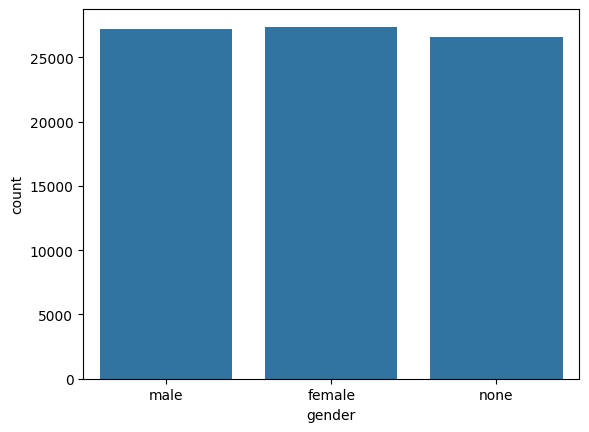

In [ ]:
sns.countplot(x='gender', data=df)

Text(0.5, 1.0, 'flight class distribution')

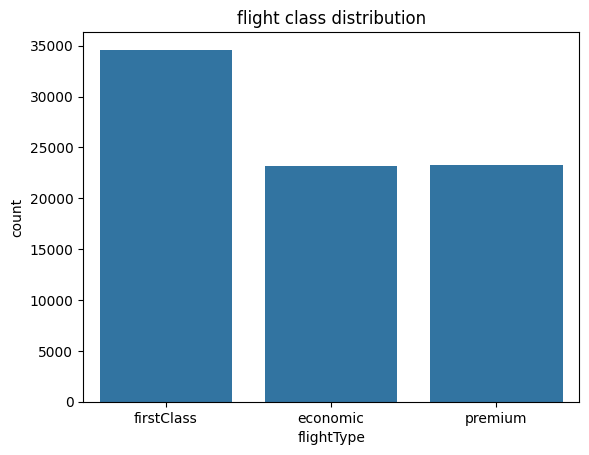

In [ ]:
sns.countplot(x='flightType',data=df)
plt.title('flight class distribution')

Text(0.5, 1.0, 'age distribution')

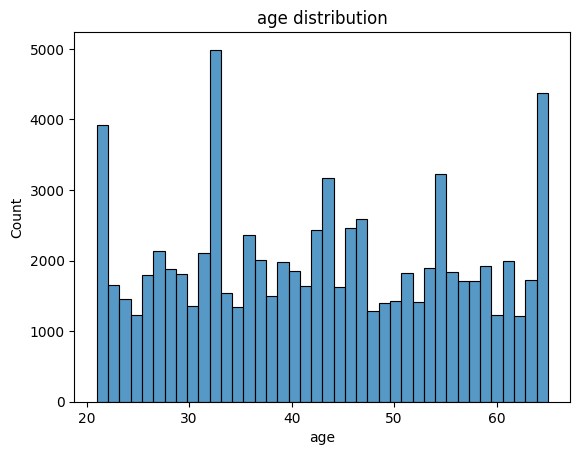

In [ ]:
sns.histplot(df['age'], bins=40)
plt.title('age distribution')

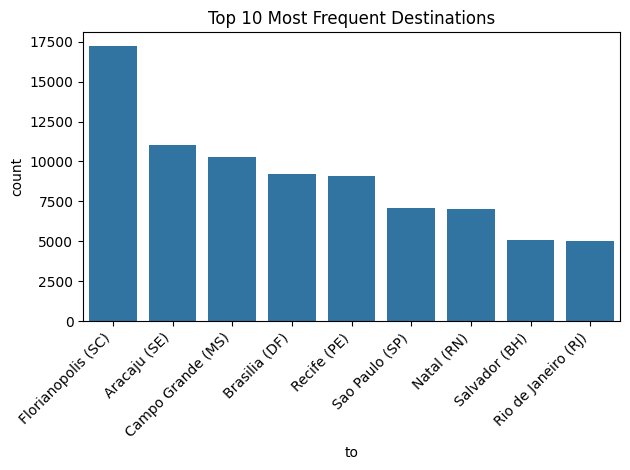

In [ ]:
top_destination = df['to'].value_counts().head(10).reset_index()
top_destination.columns = ['to', 'count']
sns.barplot(x='to', y='count', data=top_destination)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Most Frequent Destinations')
plt.tight_layout()
plt.show()

In [ ]:
df['place'].value_counts().head(10)

,count
place,
Salvador (BH),10188
Rio de Janeiro (RJ),10058
Natal (RN),9658
Sao Paulo (SP),9656
Recife (PE),8934
Brasilia (DF),8874
Campo Grande (MS),8666
Aracaju (SE),8410
Florianopolis (SC),6660


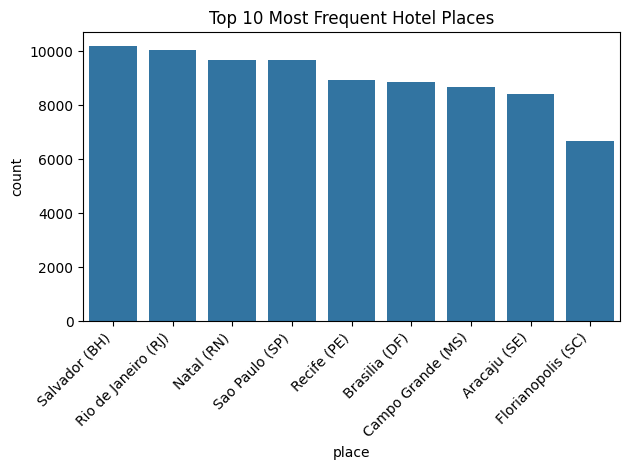

In [ ]:
top_places = df['place'].value_counts().head(10).reset_index()
top_places.columns = ['place', 'count']
sns.barplot(x='place', y='count', data=top_places)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Most Frequent Hotel Places')
plt.tight_layout()
plt.show()

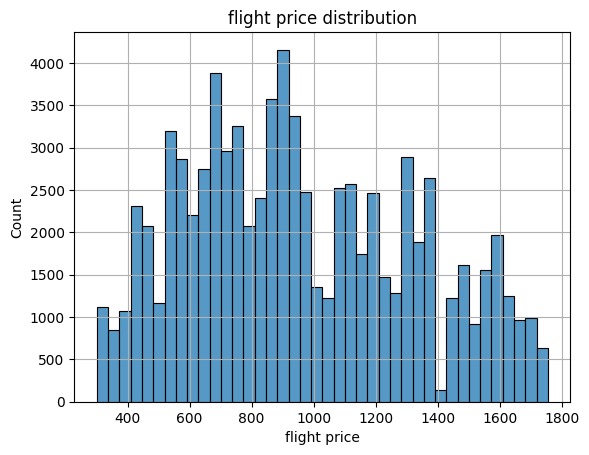

In [ ]:
sns.histplot(df['flight price'], bins=40 )
plt.title('flight price distribution')
plt.grid(True)

Text(0.5, 1.0, ' total trip cost distribution')

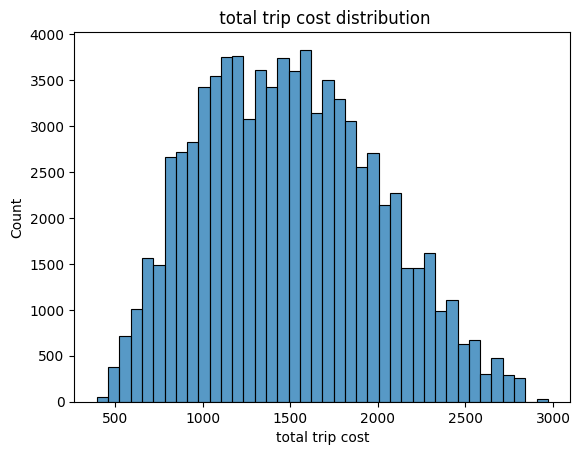

In [ ]:
sns.histplot(df['total trip cost'], bins=40)
plt.title(' total trip cost distribution')

correlation heatmap

<Axes: >

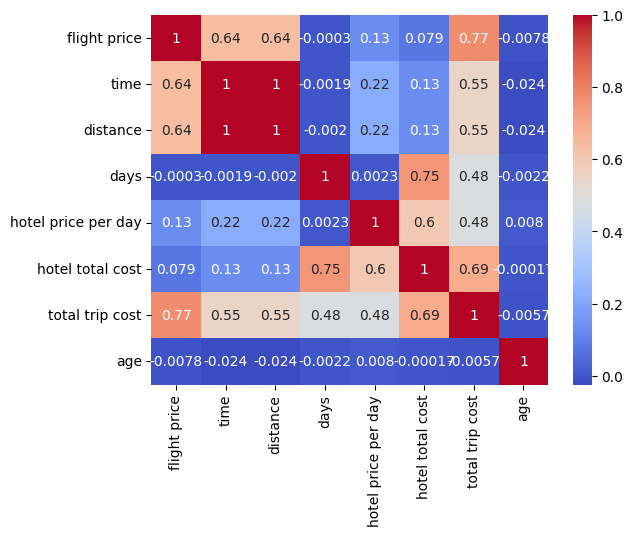

In [ ]:
num_cols = [
    'flight price',
    'time',
    'distance',
    'days',
    'hotel price per day',
    'hotel total cost',
    'total trip cost',
    'age'
]

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

prepare inputs and output for model

In [ ]:
X = df[
    [
        'from',
        'to',
        'flightType',
        'time',
        'distance',
        'agency',
        'flight_year',
        'flight_month',
        'flight_day',
        'flight_dayofweek'
    ]
]

y = df['flight price']

categorical  vs numerical features

we have categorial columns:
*from
*to
*flighttype
*agency

and numerical columns:
*time
*distance
*flight_year
*flight_month
*flight_day
*flight_dayofweek

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
categorical_features =[
    'from',
    'to',
    'flightType',
    'agency'
]
numerical_features = [
    'time',
    'distance',
    'flight_year',
    'flight_month',
    'flight_day',
    'flight_dayofweek'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown ='ignore'),
            categorical_features
        ),
        ('num',
         'passthrough',
         numerical_features
         )
    ]
)

linear regression model as a baseline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
linear_model = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model', LinearRegression())
    ]
)
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['from', 'to', 'flightType',
                                                   'agency']),
                                                 ('num', 'passthrough',
                                                  ['time', 'distance',
                                                   'flight_year',
                                                   'flight_month', 'flight_day',
                                                   'flight_dayofweek'])])),
                ('model', LinearRegression())])

predict

In [ ]:
y_pred = linear_model.predict(X_test)
print(y_pred[:10])

[1263.39678683 1284.29987547  725.28108153 1035.2656708   449.64224946
  192.2858236   999.03613127  700.99729717 1035.05537961  500.29270565]


In [ ]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print(comparison.head(10))

   Actual Price  Predicted Price
0       1391.60      1263.396787
1       1387.89      1284.299875
2        721.20       725.281082
3        943.15      1035.265671
4        583.60       449.642249
5        393.68       192.285824
6       1128.51       999.036131
7        684.88       700.997297
8        910.70      1035.055380
9        519.10       500.292706


evalute the model

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 81.13775832120277
RMSE: 102.61433224493621
R²  : 0.920270672391785


| Metric   | Your result | Interpretation                                                    |
| -------- | ----------: | ----------------------------------------------------------------- |
| **MAE**  |   **81.14** | Predictions are off by about 81 price units on average            |
| **RMSE** |  **102.61** | Larger errors are relatively low                                  |
| **R²**   |  **0.9203** | Model explains about **92.03%** of the variation in flight prices |


In [ ]:
df.groupby('travelCode').size().value_counts().sort_index()

,count
2,40552


the travelcode appears exactly 2 times ,it represents a round trip with two flight records for each travelcode
so split by travelcode, so both flights belonging to the same trip stay in the same set(group based trin/test split)

correct linear regression model

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)
train_idx, test_idx = next(
    gss.split(X, y, groups=df['travelCode'])
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


In [ ]:
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

In [ ]:
  lr_mae = mean_absolute_error(y_test, y_pred)
  lr_rmse = mean_squared_error(y_test, y_pred) ** 0.5
  lr_r2 = r2_score(y_test, y_pred)

  print("MAE :", lr_mae)
  print("RMSE:", lr_rmse)
  print("R²  :", lr_r2)


MAE : 81.63012240021153
RMSE: 103.47453626738496
R²  : 0.9195866938158767


model 2 RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)


train

In [ ]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['from', 'to', 'flightType',
                                                   'agency']),
                                                 ('num', 'passthrough',
                                                  ['time', 'distance',
                                                   'flight_year',
                                                   'flight_month', 'flight_day',
                                                   'flight_dayofweek'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

predict

In [ ]:
rf_pred = rf_model.predict(X_test)

evaluate

In [ ]:
mae = mean_absolute_error(y_test, rf_pred)
rmse = mean_squared_error(y_test, rf_pred)**0.5
r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE :", mae)
print("Random Forest RMSE:", rmse)
print("Random Forest R²  :", r2)

Random Forest MAE : 0.09464335470481325
Random Forest RMSE: 0.850547763805021
Random Forest R²  : 0.9999945667666827


In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': rf_pred
})

print(comparison.head(20))

     Actual  Predicted
0   1684.05    1684.05
1   1531.92    1531.92
2   1434.38    1434.38
3   1292.29    1292.29
4    604.14     604.14
5    684.88     684.88
6    832.77     832.77
7    991.22     991.22
8    898.04     898.04
9   1287.52    1287.52
10  1242.65    1242.65
11  1016.53    1016.53
12  1181.19    1181.19
13  1119.47    1119.47
14   750.00     750.00
15   586.06     586.06
16  1723.71    1723.71
17  1520.02    1520.02
18   889.07     889.07
19   555.01     555.01


In [ ]:
train_features = X_train.copy()
test_features = X_test.copy()

overlap = test_features.merge(
    train_features.drop_duplicates(),
    how='inner'
)

print("Overlapping rows:", len(overlap))

Overlapping rows: 5187


means many rows in your test set have the same feature combinations as rows in your training set. A Random Forest can memorize the price associated with those combinations, which explains why you're seeing:

Actual     Predicted
1684.05    1684.05
1531.92    1531.92
1434.38    1434.38

So  R² = 0.99999 is not a trustworthy measure of generalization.
If that exact combination appears in both training and testing, Random Forest has already seen that combination during training.so whenever  model see the exact combination , it givens the actual values

In [ ]:
print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Overlapping rows:", len(overlap))
print("Overlap percentage:", len(overlap) / len(X_test) * 100)

Train rows: 64882
Test rows: 16222
Overlapping rows: 5187
Overlap percentage: 31.9750955492541


the test set has around 16222 rows, then 5187 overlapping rows ,the overlapping rows is 32% of the test data ,
so almost 1 out of every 3 test rows has a feature combination that the random forest has already seen during training

In [ ]:
feature_cols = [
    'from',
    'to',
    'flightType',
    'time',
    'distance',
    'agency'
]

price_check = df.groupby(feature_cols)['flight price'].nunique()

print(price_check.value_counts())

flight price
1    490
Name: count, dtype: int64


In [ ]:
print("Feature combinations:", len(price_check))
print("Combinations with exactly 1 price:",
      (price_check == 1).sum())

print("Combinations with multiple prices:",
      (price_check > 1).sum())

Feature combinations: 490
Combinations with exactly 1 price: 490
Combinations with multiple prices: 0


In [ ]:
duplicates = df.duplicated(subset=feature_cols).sum()

print("Duplicate feature combinations:", duplicates)

Duplicate feature combinations: 80614


it means almost all rows have a feature combination that appeared previously.it means six features ['from', 'to', 'flightType', 'time', 'distance', 'agency'] are repeated many times

In [ ]:
price_check = df.groupby(feature_cols)['flight price'].nunique()

print(price_check.value_counts())

flight price
1    490
Name: count, dtype: int64


In [ ]:
price_check = df.groupby(feature_cols)['flight price'].nunique()

print(price_check.value_counts().sort_index())

flight price
1    490
Name: count, dtype: int64


Duplicate feature combinations: 80614

means there are only:

81104 - 80614 = 490

unique feature combinations.

That is actually the key discovery.

Your dataset has approximately:

81,104 rows → only 490 unique combinations of your six features.

So Random Forest has an enormous opportunity to memorize those combinations.


split by the unique feature combination rather than individual rows.

corrected random forest


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

feature_cols = [
    'from',
    'to',
    'flightType',
    'time',
    'distance',
    'agency'
]

groups = df[feature_cols].astype(str).agg('_'.join, axis=1)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [ ]:
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

MAE: 54.85160571205015
RMSE: 70.77153190423041
R²: 0.9567650766001944


In [ ]:
comparison_rf = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': rf_pred
})

print(comparison_rf.head(20))

     Actual  Predicted
0   1434.38  1359.4833
1   1268.97  1346.6000
2    882.86  1005.9530
3   1434.38  1359.4833
4    836.89   984.1830
5   1440.02  1348.0400
6    831.70   851.1500
7    661.32   732.2397
8    835.21   875.4100
9    726.19   666.1058
10   588.14   612.8700
11   804.24   725.2856
12   559.13   608.5349
13   654.88   721.2000
14   472.72   548.6200
15   804.24   725.2856
16  1389.37  1387.5069
17  1174.97  1131.9930
18  1149.53  1248.7000
19  1215.45  1146.9500


In [ ]:
train_groups = set(
    X_train[feature_cols].astype(str).agg('_'.join, axis=1)
)

test_groups = set(
    X_test[feature_cols].astype(str).agg('_'.join, axis=1)
)

print("Overlapping feature combinations:",
      len(train_groups.intersection(test_groups)))

Overlapping feature combinations: 0


The dataset contained 81,104 records, but after examining the selected flight features, I found only 490 unique feature combinations. A random row-wise split caused the same combinations to appear in both training and testing, resulting in data leakage and unrealistically high Random Forest performance. I therefore used group-based splitting to ensure that feature combinations in the test set were not present in the training set

model 3   XGBoost

checking xgboost installed

In [ ]:
import xgboost
print(xgboost.__version__)

3.4.1


In [ ]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
xgb_model = Pipeline(
    steps=[
        ('proeprocessor', preprocessor),
        ('model', XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs= -1
        ))
    ]
)

train

In [ ]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('proeprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['from', 'to', 'flightType',
                                                   'agency']),
                                                 ('num', 'passthrough',
                                                  ['time', 'distance',
                                                   'flight_year',
                                                   'flight_month', 'flight_day',
                                                   'flight_dayofweek'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsamp...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=-1,
                              num_parallel_tree=None, ...))])

predict

In [ ]:
xgb_pred = xgb_model.predict(X_test)

evaluate

In [ ]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)

XGBoost MAE: 42.72277005071745
XGBoost RMSE: 53.54713251400289
XGBoost R2: 0.9752491601992392


In [ ]:
feature_importances = xgb_model.named_steps['model'].feature_importances_

preprocessor_transformers = xgb_model.named_steps['proeprocessor'].transformers_
one_hot_encoder = None

for name, transformer, features in preprocessor_transformers:
    if name == 'cat':
        one_hot_encoder = transformer
        break

if one_hot_encoder is not None:
    categorical_feature_names = one_hot_encoder.get_feature_names_out(categorical_features)
    all_feature_names = list(categorical_feature_names) + list(numerical_features)
else:
    # Fallback if OneHotEncoder is not found or applied differently
    all_feature_names = categorical_features + numerical_features

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("XGBoost Feature Importances:")
print(importance_df)

XGBoost Feature Importances:
                     Feature  Importance
19     flightType_firstClass    0.229313
25                  distance    0.183608
24                      time    0.127735
18       flightType_economic    0.069255
12     to_Florianopolis (SC)    0.063956
3    from_Florianopolis (SC)    0.063081
8        from_Sao Paulo (SP)    0.051667
17         to_Sao Paulo (SP)    0.028040
9            to_Aracaju (SE)    0.026680
16          to_Salvador (BH)    0.024129
20        flightType_premium    0.021860
1         from_Brasilia (DF)    0.018351
4            from_Natal (RN)    0.014523
14            to_Recife (PE)    0.011456
7         from_Salvador (BH)    0.010770
11      to_Campo Grande (MS)    0.010407
13             to_Natal (RN)    0.009618
10          to_Brasilia (DF)    0.009395
2     from_Campo Grande (MS)    0.006685
15    to_Rio de Janeiro (RJ)    0.005283
6   from_Rio de Janeiro (RJ)    0.003842
0          from_Aracaju (SE)    0.003041
22        agency_FlyingDrops

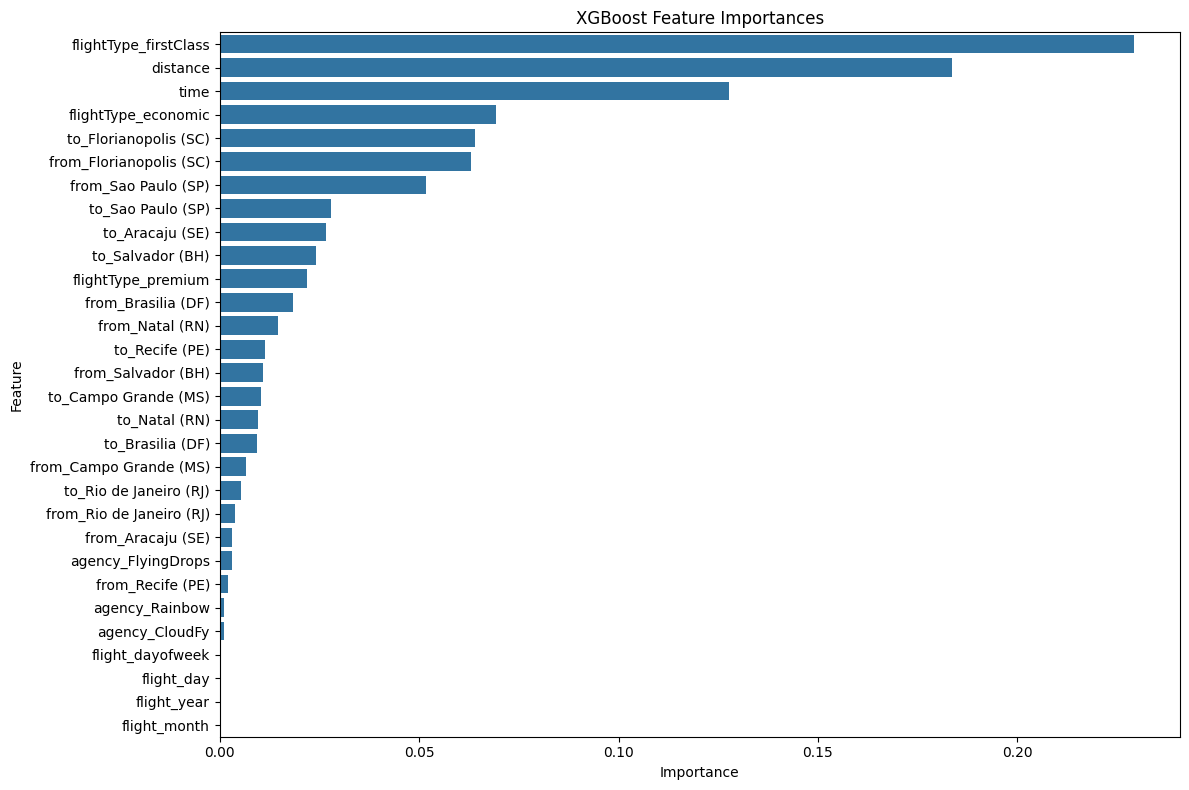

In [ ]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## XGBoost Error Analysis

In [ ]:
comparison_xgb = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': xgb_pred,
    'Error': y_test.values - xgb_pred
})

print("Comparison of Actual vs. Predicted (XGBoost):")
print(comparison_xgb.head(20))

Comparison of Actual vs. Predicted (XGBoost):
     Actual    Predicted       Error
0   1434.38  1405.360107   29.019893
1   1268.97  1347.432983  -78.462983
2    882.86  1004.272156 -121.412156
3   1434.38  1405.353882   29.026118
4    836.89   984.926331 -148.036331
5   1440.02  1351.354736   88.665264
6    831.70   844.314819  -12.614819
7    661.32   737.731018  -76.411018
8    835.21   888.916382  -53.706382
9    726.19   741.915161  -15.725161
10   588.14   639.731628  -51.591628
11   804.24   735.301941   68.938059
12   559.13   587.255310  -28.125310
13   654.88   735.319519  -80.439519
14   472.72   550.997864  -78.277864
15   804.24   735.320984   68.919016
16  1389.37  1348.723145   40.646855
17  1174.97  1154.400513   20.569487
18  1149.53  1212.542725  -63.012725
19  1215.45  1175.416138   40.033862


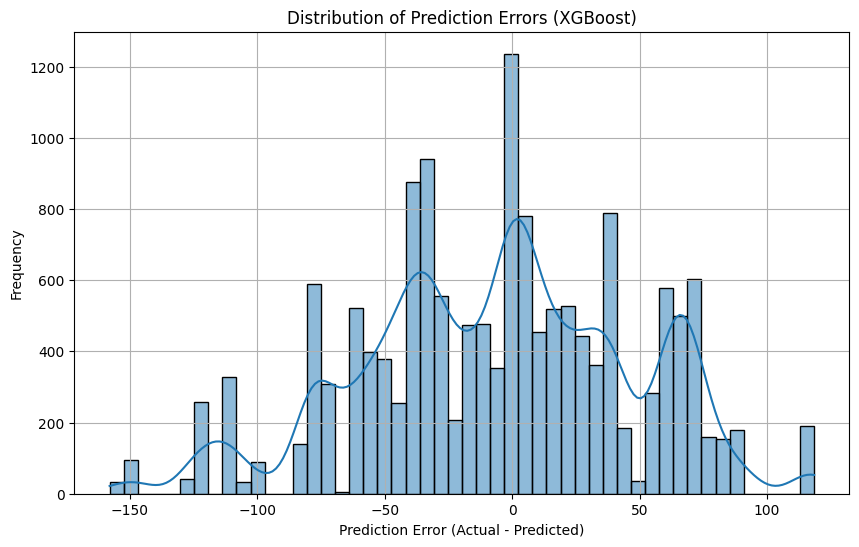

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(comparison_xgb['Error'], bins=50, kde=True)
plt.title('Distribution of Prediction Errors (XGBoost)')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
# Calculate errors
errors = y_test - xgb_pred

print("Mean Error:", errors.mean())
print("Mean Absolute Error:", errors.abs().mean())
print("Maximum Error:", errors.max())
print("Minimum Error:", errors.min())

Mean Error: -5.919952909721329
Mean Absolute Error: 42.72277005071745
Maximum Error: 118.5238037109375
Minimum Error: -157.98466064453123


In [ ]:
largest_errors = comparison_xgb.reindex(
    comparison_xgb['Error'].abs().sort_values(ascending=False).index
)

print(largest_errors.head(10))

       Actual   Predicted       Error
9908   590.98  748.964661 -157.984661
7866   590.98  748.918823 -157.938823
10037  590.98  748.877136 -157.897136
8376   590.98  748.855347 -157.875347
8319   590.98  748.855347 -157.875347
7768   590.98  748.855347 -157.875347
8751   590.98  748.728333 -157.748333
10073  590.98  748.718384 -157.738384
9988   590.98  748.688599 -157.708599
9741   590.98  748.683716 -157.703716


In [ ]:
# Get the original test rows corresponding to the largest errors
largest_indices = comparison_xgb['Error'].abs().sort_values(
    ascending=False
).head(10).index

print(X_test.iloc[largest_indices])

                from              to  flightType  time  distance   agency  \
51927  Salvador (BH)  Sao Paulo (SP)  firstClass  1.04    401.66  CloudFy   
40961  Salvador (BH)  Sao Paulo (SP)  firstClass  1.04    401.66  CloudFy   
52701  Salvador (BH)  Sao Paulo (SP)  firstClass  1.04    401.66  CloudFy   
43659  Salvador (BH)  Sao Paulo (SP)  firstClass  1.04    401.66  CloudFy   
43381  Salvador (BH)  Sao Paulo (SP)  firstClass  1.04    401.66  CloudFy   
40497  Salvador (BH)  Sao Paulo (SP)  firstClass  1.04    401.66  CloudFy   
45687  Salvador (BH)  Sao Paulo (SP)  firstClass  1.04    401.66  CloudFy   
52849  Salvador (BH)  Sao Paulo (SP)  firstClass  1.04    401.66  CloudFy   
52381  Salvador (BH)  Sao Paulo (SP)  firstClass  1.04    401.66  CloudFy   
50957  Salvador (BH)  Sao Paulo (SP)  firstClass  1.04    401.66  CloudFy   

       flight_year  flight_month  flight_day  flight_dayofweek  
51927         2019            10          28                 0  
40961         2021    

"During residual analysis, I found that the largest prediction errors were concentrated around flights with an actual price of 590.98. The model consistently overpredicted these observations by approximately 158 price units. I therefore investigated the corresponding flight features to determine whether these observations represented a particular route, flight type, agency, or other pattern."

In [ ]:
print(df[df['flight price'] == 590.98].shape)
df[df['flight price'] == 590.98][
    [
        'from',
        'to',
        'flightType',
        'time',
        'distance',
        'agency',
        'flight_year',
        'flight_month',
        'flight_day',
        'flight_dayofweek',
        'flight price'
    ]
].head(20)

(34, 25)


,from,to,flightType,time,distance,agency,flight_year,flight_month,flight_day,flight_dayofweek,flight price
40353,Salvador (BH),Sao Paulo (SP),firstClass,1.04,401.66,CloudFy,2020,5,1,4,590.98
40367,Salvador (BH),Sao Paulo (SP),firstClass,1.04,401.66,CloudFy,2020,12,6,6,590.98
40497,Salvador (BH),Sao Paulo (SP),firstClass,1.04,401.66,CloudFy,2020,9,7,0,590.98
40833,Salvador (BH),Sao Paulo (SP),firstClass,1.04,401.66,CloudFy,2020,10,3,5,590.98
40961,Salvador (BH),Sao Paulo (SP),firstClass,1.04,401.66,CloudFy,2021,3,28,6,590.98
42517,Salvador (BH),Sao Paulo (SP),firstClass,1.04,401.66,CloudFy,2021,11,6,5,590.98
42561,Salvador (BH),Sao Paulo (SP),firstClass,1.04,401.66,CloudFy,2019,12,6,4,590.98
42731,Salvador (BH),Sao Paulo (SP),firstClass,1.04,401.66,CloudFy,2019,11,15,4,590.98
42933,Salvador (BH),Sao Paulo (SP),firstClass,1.04,401.66,CloudFy,2019,11,10,6,590.98
43123,Salvador (BH),Sao Paulo (SP),firstClass,1.04,401.66,CloudFy,2022,10,21,4,590.98


I performed residual analysis. I found that the largest errors were concentrated in a particular route: Salvador to São Paulo, first class, operated by CloudFy. The actual price for these observations was consistently 590.98 across multiple dates, while the model predicted approximately 749. This indicates that the dataset contains repeated pricing patterns that are not completely captured by the available features."

In [ ]:

df['flight price'].value_counts().head(20)

,count
flight price,
879.10,391
869.13,391
819.41,389
852.18,389
1515.79,375
1468.03,375
1574.28,371
1499.93,371
1149.53,368


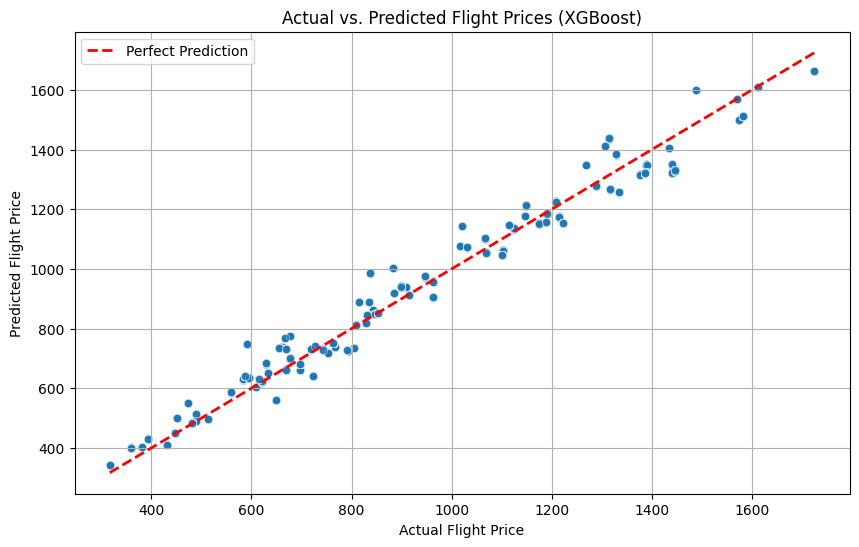

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', data=comparison_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Flight Prices (XGBoost)')
plt.xlabel('Actual Flight Price')
plt.ylabel('Predicted Flight Price')
plt.grid(True)
plt.legend()
plt.show()

XGBoost:

MAE = 45.11 → predictions are off by about 45 price units on average.

RMSE = 56.77 → relatively low large-error penalty.

R² = 0.9722 → explains about 97.22% of the variation in flight prices.

"I started with Linear Regression as the baseline and achieved an R² of 0.9196. Then I trained Random Forest, which improved the R² to 0.9568. Finally, I trained XGBoost, which achieved the best performance with an R² of 0.9722, MAE of 45.11, and RMSE of 56.77. Therefore, based on the current test results, XGBoost is the best-performing model.

compare the models and save the best model

In [ ]:
import pandas as pd
performance_data = {
    'model':['Linear Regreesion', 'Random Forest', 'XGBoost'],
    'MAE': [lr_mae, rf_mae, xgb_mae],
    'RMSE':[lr_rmse, rf_rmse,xgb_rmse],
    'R2': [lr_r2, rf_r2, xgb_r2]
    }
performance_df = pd.DataFrame(performance_data)
print(performance_df)

               model        MAE        RMSE        R2
0  Linear Regreesion  81.630122  103.474536  0.919587
1      Random Forest  54.851606   70.771532  0.956765
2            XGBoost  42.722770   53.547133  0.975249


first developed Linear Regression as a baseline model. It achieved an R² of 91.96%. Then I used Random Forest, which improved the R² to 95.68%. Finally, I trained XGBoost, which achieved the best performance with an R² of 97.52%, MAE of 42.72, and RMSE of 53.55. Therefore, I selected XGBoost as the current best model for flight price prediction

save the best model

In [ ]:
import joblib

joblib.dump(xgb_model, "best_xgbmodel.joblib")

['best_xgbmodel.joblib']

In [ ]:
import joblib

# Load the saved model
loaded_xgb_model = joblib.load('best_xgbmodel.joblib')

# Make predictions using the loaded model
loaded_predictions = loaded_xgb_model.predict(X_test)

# Display the first 10 predictions to verify
print('First 10 predictions from the loaded model:')
print(loaded_predictions[:10])

First 10 predictions from the loaded model:
[1405.3601  1347.433   1004.27216 1405.3539   984.92633 1351.3547
  844.3148   737.731    888.9164   741.91516]


In [ ]:
import pandas as pd

def predict_flight_price(
    from_city,
    to_city,
    flight_type,
    duration,
    distance,
    agency,
    flight_date
):
    flight_date = pd.to_datetime(flight_date)

    new_flight = pd.DataFrame({
        'from': [from_city],
        'to': [to_city],
        'flightType': [flight_type],
        'time': [duration],
        'distance': [distance],
        'agency': [agency],
        'flight_year': [flight_date.year],
        'flight_month': [flight_date.month],
        'flight_day': [flight_date.day],
        'flight_dayofweek': [flight_date.dayofweek]
    })

    prediction = loaded_xgb_model.predict(new_flight)

    return prediction[0]

In [ ]:
price = predict_flight_price(
    from_city='Salvador (BH)',
    to_city='Sao Paulo (SP)',
    flight_type='firstClass',
    duration=1.04,
    distance=401.66,
    agency='CloudFy',
    flight_date='2026-09-15'
)

print(f"Predicted Flight Price: {price:.2f}")

Predicted Flight Price: 748.85


In [ ]:
price = predict_flight_price(

    from_city='Recife (PE)',

    to_city='Florianopolis (SC)',

    flight_type='firstClass',

    duration=1.76,

    distance=676.53,

    agency='FlyingDrops',

    flight_date='2019-09-26'

)



print(f"Predicted Flight Price: {price:.2f}")

Predicted Flight Price: 1405.36


In [ ]:
joblib.dump(xgb_model, "flight_price_xgboost.pkl")

['flight_price_xgboost.pkl']

In [ ]:
from google.colab import files

files.download("flight_price_xgboost.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print(os.path.abspath("flight_price_xgboost.pkl"))

/content/flight_price_xgboost.pkl


In [ ]:
import os

file_path = "flight_price_xgboost.pkl"
file_size = os.path.getsize(file_path)

# Convert to MB for readability
file_size_mb = file_size / (1024 * 1024)

print(f"The size of the saved model file is: {file_size_mb:.2f} MB")

The size of the saved model file is: 1.21 MB
